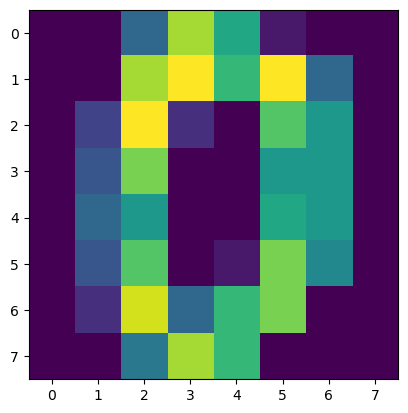

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.6922 - val_loss: 0.6761
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6680 - val_loss: 0.6536
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6453 - val_loss: 0.6310
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6218 - val_loss: 0.6066
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5963 - val_loss: 0.5801
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5690 - val_loss: 0.5523
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5413 - val_loss: 0.5250
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5148 - val_loss: 0.5001
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4912 - val_loss: 0.4790
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4714 - val_loss: 0.4621
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4558 - val_loss: 0.4489
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4438 - val_lo

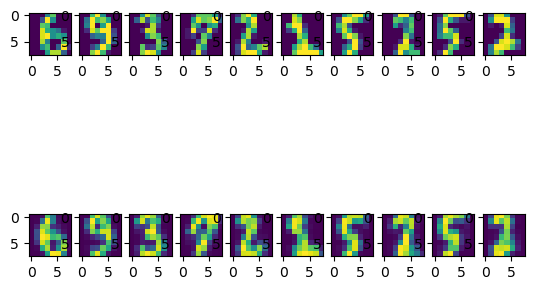

In [14]:
import os

# --- Configuración del Entorno ---
# Desactiva optimizaciones de floating-point que pueden causar variaciones mínimas en resultados
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
# Filtra logs de TensorFlow: '2' muestra solo errores, ocultando avisos de compilación/CPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

# --- Carga y Visualización de Datos ---
digitos = load_digits()

# Visualización del primer dígito (índice 0)
# Se hace un .reshape(8,8) porque los datos vienen como un vector plano de 64 elementos
plt.imshow(digitos.data[0].reshape(8, 8))
plt.show() # Añadido para que la gráfica se despliegue correctamente

# --- Preprocesamiento ---
X = digitos.data

# Normalización: Los valores de los píxeles en load_digits van de 0 a 16.
# Dividir entre 16 escala los datos al rango [0, 1], facilitando la convergencia de la red.
X = X / 16.0

# División de datos: 80% para entrenamiento y 20% para pruebas
X_entrena, X_prueba = train_test_split(X, test_size=0.2, random_state=42)

# --- Arquitectura del Autoencoder (API Funcional) ---

# 1. Capa de Entrada: Recibe vectores de 64 elementos (el tamaño de la imagen 8x8)
imagen_entrada = Input(shape=(64, ))

# 2. Encoder (Codificador):
# Reduce la dimensión de 64 a 32 neuronas. Aquí ocurre la compresión.
codificado = Dense(32, activation='relu')(imagen_entrada)

# 3. Decoder (Decodificador):
# Intenta reconstruir la imagen original a partir de la representación comprimida.
# Se usa 'sigmoid' porque los datos de entrada están normalizados entre 0 y 1.
decodificado = Dense(64, activation='sigmoid')(codificado)

# Definir el modelo completo
autoencoder = Model(imagen_entrada, decodificado)

# Compilación (usamos binary_crossentropy porque normalizamos a [0, 1])
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento
# Nota: En autoencoders, la entrada (X) es igual al objetivo (y)
autoencoder.fit(X_entrena, X_entrena, epochs=100, batch_size=256, shuffle=True, validation_data=(X_prueba, X_prueba))

for i in range(10):
    plt.subplot(2, 
                10,
                i + 1)
    plt.imshow(X_prueba[i].reshape(8,8))
    plt.subplot(2,
                10,
                i + 1 + 10)
    plt.imshow(autoencoder.predict(X_prueba)[i].reshape(8,8));
plt.show()